# Human Dorsolateral Prefrontal Cortex Visium — TOAST Alignment Evaluation

This notebook reproduces the evaluation of TOAST on the human dorsolateral prefrontal cortex (DLPFC) dataset described in the paper (Figure 3, *"Intra- and intersample and temporal alignment"*).

The goal is to benchmark the TOAST objective against classical Fused Gromov-Wasserstein (FGW) for aligning spatially resolved tissue slices across three experiment types: **consecutive** slices, **non-consecutive** slices from the same brain, and **cross-sample** slices from different donor brains. Performance is measured by alignment accuracy and Jensen-Shannon divergence of local cell-type neighborhoods.

In [1]:
import numpy as np
import pandas as pd
from spatial_OT.OT import *
from spatial_OT.utils import *
from scipy.spatial import distance
import numpy as np
import scanpy as sc
import anndata as ad
import ot
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings('ignore')

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


## Dataset

The DLPFC dataset was generated with 10× Visium (Maynard et al., 2021) and consists of **12 tissue slices** spanning six neuronal layers plus white matter from **three human brains**. Slices are numbered 151507–151510 (Sample I), 151669–151672 (Sample II), and 151673–151676 (Sample III). Manual layer annotations are provided as ground-truth labels and used to evaluate alignment accuracy. Data is sourced from the [spatialLIBD](https://research.libd.org/spatialLIBD/) resource.

In [43]:
	
consecutive = [["151507", "151508"], ["151508", "151509"], ["151509", "151510"],
                ["151669", "151670"], ["151670", "151671"], ["151671", "151672"],
                ["151673", "151674"], ["151674", "151675"], ["151675", "151676"]]

non_consecutive = [["151507", "151509"], ["151507", "151510"], ["151508", "151510"],
                ["151669", "151671"], ["151669", "151672"], ["151670", "151672"],
                ["151673", "151675"], ["151673", "151676"], ["151674", "151676"]]

cross_sample = [["151507", "151669"], ["151507", "151673"], ["151669", "151673"],
                ["151508", "151670"], ["151508", "151674"], ["151670", "151674"],
                ["151509", "151671"], ["151509", "151675"], ["151671", "151675"],
                ["151510", "151672"], ["151510", "151676"], ["151672", "151676"]]

## Experiment Design

Following the evaluation in Figure 3D of the paper, pairwise slice alignments are organised into three groups that reflect increasing biological and structural distance between slices:

| Group | Description | Example pair |
|---|---|---|
| **Consecutive** | Adjacent sections, ~10 µm apart. Minimal divergence in layer proportions. | 151507 – 151508 |
| **Non-consecutive** | Same brain, one or more sections apart. Greater divergence in tissue structure. | 151507 – 151509 |
| **Cross-sample** | Different donor brains. Most challenging: inter-individual variability on top of structural differences. | 151507 – 151669 |

Each group contains 9 pairs (3 per sample for consecutive/non-consecutive, 12 for cross-sample).

In [44]:
# Store results
results = []

def process_slice(slice_path):
    """Load and preprocess a spatial transcriptomics slice."""
    slice_data = sc.read_visium(f"/Users/sebgoti/Downloads/LIBD_2/{slice_path}", count_file=f"{slice_path}_filtered_feature_bc_matrix.h5")
    slice_data.obs_names_make_unique()
    slice_data.var_names_make_unique()
    
    ann = pd.read_csv(f"/Users/sebgoti/Downloads/LIBD_2/{slice_path}/{slice_path}_truth.txt", sep='\t', header=None, index_col=0)
    slice_data.obs["gt"] = ann.loc[slice_data.obs.index, 1]
    
    # Remove NA cells
    slice_data = slice_data[~slice_data.obs["gt"].isna()]
    
    return slice_data

def compute_spatial_fgw_alignment(slice1, slice2, alpha, epsilon):
    """Compute FGW and FGW-SN alignment and return accuracy and JS divergence scores."""
    joint_adata = sc.concat([slice1, slice2])
    sc.pp.normalize_total(joint_adata, inplace=True)
    sc.pp.log1p(joint_adata)
    sc.pp.pca(joint_adata, n_comps=n_comps)
    joint_datamatrix = joint_adata.obsm['X_pca']
    
    X = joint_datamatrix[:slice1.shape[0], :]
    Y = joint_datamatrix[slice1.shape[0]:, :]
    
    # Compute spatial graphs
    coords1 = pd.DataFrame(slice1.obsm["spatial"], columns=["x", "y"])
    X_df = pd.DataFrame(X, columns=[f"PC{i+1}" for i in range(X.shape[1])])
    X_df["x"], X_df["y"], X_df["cell_type"] = coords1["x"].values, coords1["y"].values, slice1.obs["gt"].values

    G1 = build_knn_graph_from2d(X_df, k=k)
    X_df["spatial_entropy"] = X_df.index.map(compute_spatial_entropy(G1))
    slice1_avg_expr = compute_average_neighbor_expression(G1, pd.DataFrame(X))
    
    coords2 = pd.DataFrame(slice2.obsm["spatial"], columns=["x", "y"])
    Y_df = pd.DataFrame(Y, columns=[f"PC{i+1}" for i in range(Y.shape[1])])
    Y_df["x"], Y_df["y"], Y_df["cell_type"] = coords2["x"].values, coords2["y"].values, slice2.obs["gt"].values

    G2 = build_knn_graph_from2d(Y_df, k=k)
    Y_df["spatial_entropy"] = Y_df.index.map(compute_spatial_entropy(G2))
    slice2_avg_expr = compute_average_neighbor_expression(G2, pd.DataFrame(Y))
    
    # Compute cost matrices
    M = distance.cdist(X, Y).astype(float)
    C1 = distance.cdist(slice1.obsm["spatial"], slice1.obsm["spatial"]).astype(float)
    C2 = distance.cdist(slice2.obsm["spatial"], slice2.obsm["spatial"]).astype(float)
    C3 = np.abs(X_df["spatial_entropy"].values[:, np.newaxis] - Y_df["spatial_entropy"].values[np.newaxis, :])
    C4 = distance.cdist(slice1_avg_expr.values, slice2_avg_expr.values).astype(float)

    # Normalize matrices
    for mat in [M, C1, C2, C3, C4]:
        mat /= mat.max() if mat.max() > 0 else 1  # Avoid division by zero
    
    # Compute transport maps
    p, q = ot.unif(X.shape[0]), ot.unif(Y.shape[0])
    G0 = np.outer(p, q)

    FGW = compute_transport(G0, epsilon, alpha, C1, C2, p, q, M)
    FGW_SN = compute_transport(G0, epsilon, alpha, C1, C2, p, q, M, C3, C4)

    # Compute accuracy
    acc_fgw = compute_accuracy_max_prob(FGW, slice1.obs['gt'], slice2.obs['gt'])
    acc_fgw_sn = compute_accuracy_max_prob(FGW_SN, slice1.obs['gt'], slice2.obs['gt'])
    
    # Compute JS divergence
    js_fgw = compute_js_divergence_before_after(slice1, compute_transported_adata_argmax(slice1, slice2, FGW), k=20, cell_type_key="gt")
    js_fgw_sn = compute_js_divergence_before_after(slice1, compute_transported_adata_argmax(slice1, slice2, FGW_SN), k=20, cell_type_key="gt")

    return acc_fgw, acc_fgw_sn, js_fgw, js_fgw_sn

## TOAST Alignment Pipeline

The two helper functions implement the full TOAST alignment pipeline.

---

### `process_slice`

Loads a single Visium section with `scanpy.read_visium`, enforces unique spot and gene names, and attaches manual cortical layer annotations from the companion `_truth.txt` file. Spots without an annotation are dropped so that only labelled spots are used in downstream accuracy evaluation.

---

### `compute_spatial_fgw_alignment`

This function implements both Equation 1 (classical FGW) and Equation 5 (TOAST) from the paper and returns accuracy and JS divergence for each.

**Step 1 — Joint preprocessing** *(STAR Methods: Data preprocessing)*  
Both slices are concatenated and pre-processed jointly: library-size normalisation (`sc.pp.normalize_total`), log-transformation (`sc.pp.log1p`), and PCA to `n_comps = 50` components. This yields a shared embedding space Z^p used for all distance computations, ensuring that feature distances are comparable across slices.

**Step 2 — Spatial graphs and spatial coherence** *(Equation 2)*  
A k-nearest-neighbour graph G is built from the (x, y) spatial coordinates of each slice. For every spot i, the *spatial coherence score* is computed as the Shannon entropy of the cell-type label distribution in its local neighbourhood:

> H(i) = −∑_k P_i(k) log P_i(k)

A **high entropy** (H close to log|K|) indicates a disorganised region where multiple cell types co-exist; a **low entropy** indicates a homogeneous, clustered region dominated by a single cell type.

**Step 3 — Neighborhood consistency** *(Equation 4)*  
For each spot i the PCA expression profiles of its k spatial neighbours are averaged. This *neighbourhood-average profile* E_{N(i)} captures the local molecular microenvironment and is used to discourage transport plans that map spots with dissimilar local contexts.

**Step 4 — Cost matrices** *(STAR Methods: Distance functions)*  
Five matrices are assembled and normalised to [0, 1]:

| Matrix | Role | Formula |
|---|---|---|
| **M** | Wasserstein feature cost | ‖z_i − z_j‖₂² between PCA embeddings |
| **C1, C2** | Gromov-Wasserstein structural cost | ‖z_i − z_k‖₂² within each slice's spatial coordinates |
| **C3** | Spatial coherence penalty (Eq. 3) | \|H(i) − H(j)\| — penalises pairing spots from regions with different heterogeneity levels |
| **C4** | Neighbourhood consistency penalty (Eq. 4) | ‖E_{N(i)} − E_{N(j)}‖₂² — penalises pairing spots with dissimilar local molecular microenvironments |

**Step 5 — Transport plans** *(Equations 1 and 5)*  
Two transport plans are computed with uniform marginal distributions p and q:

- **FGW** (Equation 1): balances the Wasserstein term (M) and the Gromov-Wasserstein term (C1, C2) with weight α.
- **TOAST / FGW-SN** (Equation 5): extends FGW by incorporating C3 and C4 into the structural term (each weighted α/3, alongside the GW term), embedding spatial coherence and neighbourhood consistency directly into the optimisation.

Both are solved via Sinkhorn iterations with entropic regularisation ε = 0.1 and α = 0.5, providing a balanced weighting between molecular similarity and spatial topology.

**Step 6 — Evaluation metrics** *(STAR Methods: Evaluation metrics)*  
- **Accuracy**: for each source spot the most probable target spot is identified as argmax_j Π_{ij}. Accuracy is the fraction of aligned pairs sharing the same annotated cortical layer.  
- **JS Divergence (JSD)**: for each aligned pair, the Jensen-Shannon divergence between the k = 20 nearest-neighbour cell-type distributions of source and aligned target spots is computed. Lower JSD means better preservation of the local spatial cell-type composition (Figure 3C).

---
## Experiment 1 — Consecutive Slice Alignment

Pairs of directly adjacent sections (e.g. 151507–151508, separated by ~10 µm). These represent the easiest alignment scenario: the sections are nearly identical in layer composition and only minor shifts in cell-type proportions exist between them. Despite this, TOAST's topography-aware terms still improve performance by preserving the local neighbourhood structure of the well-laminated cortex (Figure 3B–C).

In [45]:
n_comps = 50  
k = 10 
alpha = 0.5  
epsilon = 0.1  

# Run for all consecutive slices
for i in consecutive:
    print(f"Processing alignment: {i[0]} - {i[1]}")
    
    # Load and process slices
    slice1 = process_slice(i[0])
    slice2 = process_slice(i[1])

    # Compute alignment
    acc_fgw, acc_fgw_sn, js_fgw, js_fgw_sn = compute_spatial_fgw_alignment(slice1, slice2, alpha, epsilon)

    # Store results
    results.append({
        "Slice1": i[0], "Slice2": i[1],
        "FGW_Accuracy": acc_fgw, "FGW-SN_Accuracy": acc_fgw_sn,
        "FGW_JS_Divergence": js_fgw, "FGW-SN_JS_Divergence": js_fgw_sn
    })

    print(f"FGW Accuracy: {acc_fgw:.3f}, FGW-SN Accuracy: {acc_fgw_sn:.3f}")
    print(f"FGW JS Divergence: {js_fgw:.4f}, FGW-SN JS Divergence: {js_fgw_sn:.4f}\n")

Processing alignment: 151507 - 151508
FGW Accuracy: 0.654, FGW-SN Accuracy: 0.733
FGW JS Divergence: 0.3281, FGW-SN JS Divergence: 0.2350

Processing alignment: 151508 - 151509
FGW Accuracy: 0.563, FGW-SN Accuracy: 0.649
FGW JS Divergence: 0.3753, FGW-SN JS Divergence: 0.2846

Processing alignment: 151509 - 151510
FGW Accuracy: 0.717, FGW-SN Accuracy: 0.766
FGW JS Divergence: 0.2670, FGW-SN JS Divergence: 0.1914

Processing alignment: 151669 - 151670
FGW Accuracy: 0.778, FGW-SN Accuracy: 0.833
FGW JS Divergence: 0.2154, FGW-SN JS Divergence: 0.1371

Processing alignment: 151670 - 151671
FGW Accuracy: 0.738, FGW-SN Accuracy: 0.794
FGW JS Divergence: 0.2357, FGW-SN JS Divergence: 0.1491

Processing alignment: 151671 - 151672
FGW Accuracy: 0.809, FGW-SN Accuracy: 0.854
FGW JS Divergence: 0.2066, FGW-SN JS Divergence: 0.1234

Processing alignment: 151673 - 151674
FGW Accuracy: 0.668, FGW-SN Accuracy: 0.770
FGW JS Divergence: 0.2799, FGW-SN JS Divergence: 0.1890

Processing alignment: 15167

---
## Experiment 2 — Non-consecutive Slice Alignment

Pairs of slices from the **same brain** separated by one or more intervening sections (e.g. 151507–151509). These pairs have greater structural divergence than consecutive slices, as a larger change in layer proportions accumulates with distance. TOAST's explicit modelling of local neighbourhood structure becomes increasingly important here (Figure 3D, middle panel).

In [46]:
n_comps = 50  
k = 10 
alpha = 0.5  
epsilon = 0.1  

# Run for all consecutive slices
for i in non_consecutive:
    print(f"Processing alignment: {i[0]} - {i[1]}")
    
    # Load and process slices
    slice1 = process_slice(i[0])
    slice2 = process_slice(i[1])

    # Compute alignment
    acc_fgw, acc_fgw_sn, js_fgw, js_fgw_sn = compute_spatial_fgw_alignment(slice1, slice2, alpha, epsilon)

    # Store results
    results.append({
        "Slice1": i[0], "Slice2": i[1],
        "FGW_Accuracy": acc_fgw, "FGW-SN_Accuracy": acc_fgw_sn,
        "FGW_JS_Divergence": js_fgw, "FGW-SN_JS_Divergence": js_fgw_sn
    })

    print(f"FGW Accuracy: {acc_fgw:.3f}, FGW-SN Accuracy: {acc_fgw_sn:.3f}")
    print(f"FGW JS Divergence: {js_fgw:.4f}, FGW-SN JS Divergence: {js_fgw_sn:.4f}\n")

Processing alignment: 151507 - 151509
FGW Accuracy: 0.530, FGW-SN Accuracy: 0.611
FGW JS Divergence: 0.3780, FGW-SN JS Divergence: 0.3013

Processing alignment: 151507 - 151510
FGW Accuracy: 0.541, FGW-SN Accuracy: 0.650
FGW JS Divergence: 0.3753, FGW-SN JS Divergence: 0.2972

Processing alignment: 151508 - 151510
FGW Accuracy: 0.536, FGW-SN Accuracy: 0.648
FGW JS Divergence: 0.3808, FGW-SN JS Divergence: 0.2854

Processing alignment: 151669 - 151671
FGW Accuracy: 0.711, FGW-SN Accuracy: 0.774
FGW JS Divergence: 0.2595, FGW-SN JS Divergence: 0.1840

Processing alignment: 151669 - 151672
FGW Accuracy: 0.643, FGW-SN Accuracy: 0.712
FGW JS Divergence: 0.2797, FGW-SN JS Divergence: 0.1868

Processing alignment: 151670 - 151672
FGW Accuracy: 0.667, FGW-SN Accuracy: 0.745
FGW JS Divergence: 0.2583, FGW-SN JS Divergence: 0.1633

Processing alignment: 151673 - 151675
FGW Accuracy: 0.670, FGW-SN Accuracy: 0.754
FGW JS Divergence: 0.2664, FGW-SN JS Divergence: 0.1779

Processing alignment: 15167

---
## Experiment 3 — Cross-sample Alignment

Pairs of slices from **different donor brains** (e.g. 151507 from Sample I paired with 151669 from Sample II). This is the most challenging setting: beyond structural differences between sections, inter-individual variability in layer thickness and cell-type composition must be overcome. The paper reports statistically significant improvement of TOAST over all baselines in this regime (Figure 3D, right panel, Wilcoxon rank-sum test).

In [51]:
n_comps = 50  
k = 10 
alpha = 0.5  
epsilon = 0.1  

# Run for all consecutive slices
for i in cross_sample:
    print(f"Processing alignment: {i[0]} - {i[1]}")
    
    # Load and process slices
    slice1 = process_slice(i[0])
    slice2 = process_slice(i[1])

    # Compute alignment
    acc_fgw, acc_fgw_sn, js_fgw, js_fgw_sn = compute_spatial_fgw_alignment(slice1, slice2, alpha, epsilon)

    # Store results
    results.append({
        "Slice1": i[0], "Slice2": i[1],
        "FGW_Accuracy": acc_fgw, "FGW-SN_Accuracy": acc_fgw_sn,
        "FGW_JS_Divergence": js_fgw, "FGW-SN_JS_Divergence": js_fgw_sn
    })

    print(f"FGW Accuracy: {acc_fgw:.3f}, FGW-SN Accuracy: {acc_fgw_sn:.3f}")
    print(f"FGW JS Divergence: {js_fgw:.4f}, FGW-SN JS Divergence: {js_fgw_sn:.4f}\n")

Processing alignment: 151507 - 151669
FGW Accuracy: 0.464, FGW-SN Accuracy: 0.494
FGW JS Divergence: 0.3632, FGW-SN JS Divergence: 0.3033

Processing alignment: 151507 - 151673
FGW Accuracy: 0.492, FGW-SN Accuracy: 0.691
FGW JS Divergence: 0.3789, FGW-SN JS Divergence: 0.2821

Processing alignment: 151669 - 151673
FGW Accuracy: 0.335, FGW-SN Accuracy: 0.533
FGW JS Divergence: 0.2768, FGW-SN JS Divergence: 0.2014

Processing alignment: 151508 - 151670
FGW Accuracy: 0.431, FGW-SN Accuracy: 0.464
FGW JS Divergence: 0.3895, FGW-SN JS Divergence: 0.3194

Processing alignment: 151508 - 151674
FGW Accuracy: 0.379, FGW-SN Accuracy: 0.596
FGW JS Divergence: 0.4243, FGW-SN JS Divergence: 0.3267

Processing alignment: 151670 - 151674
FGW Accuracy: 0.339, FGW-SN Accuracy: 0.506
FGW JS Divergence: 0.2740, FGW-SN JS Divergence: 0.1859

Processing alignment: 151509 - 151671
FGW Accuracy: 0.309, FGW-SN Accuracy: 0.303
FGW JS Divergence: 0.3745, FGW-SN JS Divergence: 0.3138

Processing alignment: 15150

---
## Results Summary

Bar charts compare FGW and TOAST (FGW-SN) across all 30 pairwise alignments (9 consecutive + 9 non-consecutive + 12 cross-sample) on two metrics:

- **Accuracy** (higher is better): proportion of spots correctly matched to a target spot of the same annotated cortical layer.
- **Neighbourhood JS Divergence** (lower is better): mean Jensen-Shannon divergence between the cell-type distributions of the 20 nearest neighbours of each aligned spot pair. A lower value means the local spatial organisation is better preserved after alignment.

The mean scores printed below the plots summarise the overall advantage of TOAST over FGW across all alignment scenarios.

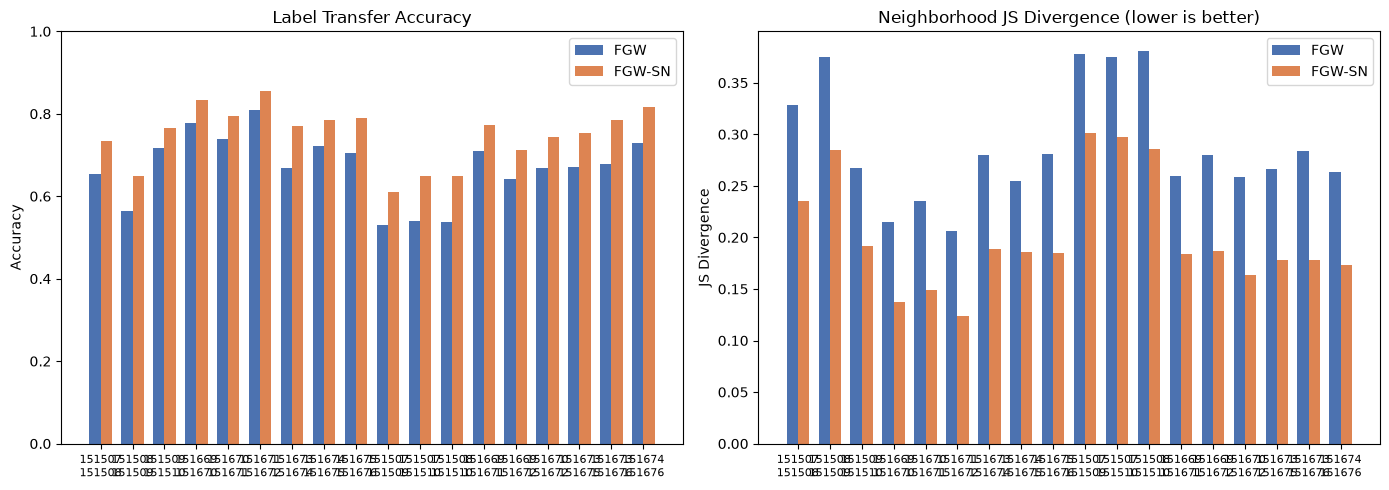

Mean Accuracy     — FGW: 0.670,  FGW-SN: 0.748
Mean JS Divergence — FGW: 0.2883, FGW-SN: 0.2015


In [47]:
df = pd.DataFrame(results)
df["Pair"] = df["Slice1"] + "\n" + df["Slice2"]

x = np.arange(len(df))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(x - width/2, df["FGW_Accuracy"],    width, label="FGW",    color="#4C72B0")
ax.bar(x + width/2, df["FGW-SN_Accuracy"], width, label="FGW-SN", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(df["Pair"], fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Label Transfer Accuracy")
ax.legend()

ax = axes[1]
ax.bar(x - width/2, df["FGW_JS_Divergence"],    width, label="FGW",    color="#4C72B0")
ax.bar(x + width/2, df["FGW-SN_JS_Divergence"], width, label="FGW-SN", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(df["Pair"], fontsize=8)
ax.set_ylabel("JS Divergence")
ax.set_title("Neighborhood JS Divergence (lower is better)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean Accuracy     — FGW: {df['FGW_Accuracy'].mean():.3f},  FGW-SN: {df['FGW-SN_Accuracy'].mean():.3f}")
print(f"Mean JS Divergence — FGW: {df['FGW_JS_Divergence'].mean():.4f}, FGW-SN: {df['FGW-SN_JS_Divergence'].mean():.4f}")

---
## Spatial Visualisation — Ground Truth Cortical Layers

Each spot is coloured by its manually annotated cortical layer label (Layer 1–6 plus white matter). The DLPFC is a highly layered and spatially organised structure (Figure 3A in the paper), where distinct neuronal and glial cell populations are arranged in well-defined laminar bands. This strong spatial organisation is what makes the spatial coherence and neighbourhood consistency terms in TOAST particularly effective: the transport plan is rewarded for mapping spots that sit in equivalent layers with equivalent microenvironments, leading to more biologically meaningful cross-slice correspondences.

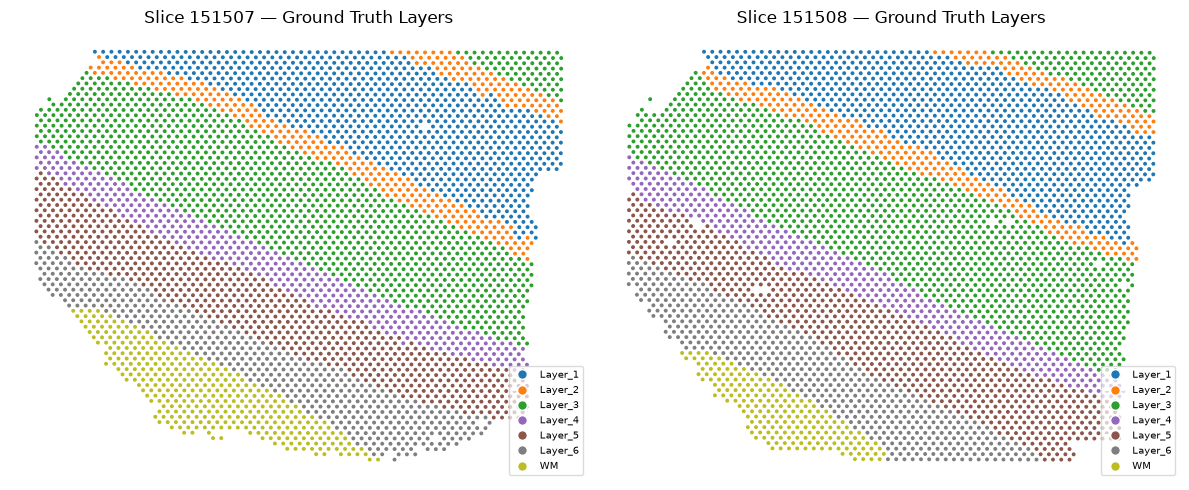

In [50]:
# Spatial visualization of ground truth layers on tissue for two example slices
slice_a = process_slice("151507")
slice_b = process_slice("151508")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, sl, title in zip(axes, [slice_a, slice_b], ["151507", "151508"]):
    coords = sl.obsm["spatial"]
    labels = sl.obs["gt"].astype("category")
    categories = labels.cat.categories
    palette = plt.colormaps["tab10"]
    color_map = {cat: palette(i / len(categories)) for i, cat in enumerate(categories)}
    colors = [color_map[l] for l in labels]

    ax.scatter(coords[:, 0], -coords[:, 1], c=colors, s=8, linewidths=0)
    ax.set_title(f"Slice {title} — Ground Truth Layers")
    ax.axis("off")
    handles = [plt.Line2D([0], [0], marker="o", color="w",
                          markerfacecolor=color_map[c], markersize=7, label=c)
               for c in categories]
    ax.legend(handles=handles, loc="lower right", fontsize=7, framealpha=0.7)

plt.tight_layout()
plt.show()